<a href="https://colab.research.google.com/github/baileysmoko/Fabric/blob/main/pf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd

url = "https://api.bybitglobal.com/v5/market/open-interest"

headers = {"User-Agent": "Mozilla/5.0"}

params = {
    "category": "linear",
    "symbol": "BTCUSDT",
    "intervalTime": "1h"
}

r = requests.get(url, params=params, headers=headers)
print("STATUS:", r.status_code)
print(r.text[:300])


STATUS: 403
403 Forbidden for your country


In [ ]:
import requests

API_KEY = "1a69537328f74ef98f3459246c190092"

headers = {"CG-API-KEY": API_KEY}

url = "https://open-api.coinglass.com/public/v2/coin/list"

r = requests.get(url, headers=headers)

print(r.status_code)
print(r.text)


500
{"timestamp":1765155613076,"status":500,"error":"Internal Server Error","message":"","path":"/public/v2/coin/list"}


In [ ]:
import requests

API_KEY = "1a69537328f74ef98f3459246c190092"
headers = {"CG-API-KEY": API_KEY}

url = "https://open-api.coinglass.com/public/v2/futures/openInterest/chart?symbol=BTC"

r = requests.get(url, headers=headers)

print("STATUS:", r.status_code)
print(r.text[:500], "...")


STATUS: 500
{"timestamp":1765155663265,"status":500,"error":"Internal Server Error","message":"","path":"/public/v2/futures/openInterest/chart"} ...


In [ ]:
import requests
print(requests.get("https://open-api.coinglass.com/public/v2/futures/openInterest/chart?symbol=BTC").status_code)


500


In [ ]:
import requests
import datetime

currency = 'BTC'
start_date = datetime.datetime(2021, 1, 1)
end_date = datetime.datetime.now()
start_timestamp = int(start_date.timestamp() * 1000)
end_timestamp = int(end_date.timestamp() * 1000)
resolution = '1D'

url = f"https://www.deribit.com/api/v2/public/get_volatility_index_data?currency={currency}&start_timestamp={start_timestamp}&end_timestamp={end_timestamp}&resolution={resolution}"

response = requests.get(url)
res_json = response.json()
print(res_json)  # Inspect the keys and structure


{'jsonrpc': '2.0', 'result': {'data': [[1678924800000, 64.15, 64.15, 56.98, 62.45], [1679011200000, 62.45, 69.46, 60.76, 66.59], [1679097600000, 66.59, 68.88, 64.07, 67.25], [1679184000000, 67.25, 74.34, 67.13, 73.34], [1679270400000, 73.34, 73.83, 68.08, 68.23], [1679356800000, 68.23, 71.75, 67.0, 70.06], [1679443200000, 68.92, 70.11, 63.29, 63.89], [1679529600000, 63.89, 67.31, 61.07, 66.43], [1679616000000, 66.43, 67.76, 64.5, 65.06], [1679702400000, 65.06, 65.19, 60.99, 61.59], [1679788800000, 61.59, 63.35, 61.48, 63.23], [1679875200000, 63.23, 65.95, 61.97, 62.12], [1679961600000, 62.12, 63.42, 59.73, 60.13], [1680048000000, 60.13, 64.96, 58.82, 64.49], [1680134400000, 64.49, 66.82, 62.34, 62.74], [1680220800000, 62.74, 62.99, 57.97, 58.52], [1680307200000, 58.52, 58.53, 57.35, 58.17], [1680393600000, 58.17, 60.65, 58.02, 60.28], [1680480000000, 60.28, 62.44, 58.38, 61.83], [1680566400000, 61.83, 61.83, 59.45, 59.65], [1680652800000, 59.65, 60.56, 57.93, 58.02], [1680739200000, 58

In [ ]:
import pprint

data = res_json.get('result', [])
print("Length of data:", len(data))
pprint.pprint(data[:5])  # show the first 5 items


Length of data: 2


KeyError: slice(None, 5, None)

In [ ]:
import requests
import pandas as pd
from datetime import datetime

# ------------------------------------------------------------
# 1. ENTER YOUR API KEY HERE
# ------------------------------------------------------------
API_KEY = "1a69537328f74ef98f3459246c190092"

headers = {
    "accept": "application/json",
    "CG-API-KEY": API_KEY
}

# ------------------------------------------------------------
# 2. CHOOSE THE ENDPOINT
# ------------------------------------------------------------
# Exchange Netflow for BTC (example)
url = "https://open-api.coinglass.com/public/v2/stat/exchange?symbol=BTC"

# If you want derivatives OI, funding rate, etc, you can swap endpoint:
# OI: https://open-api.coinglass.com/public/futures/openInterest?symbol=BTC
# Funding Rate: https://open-api.coinglass.com/public/futures/fundingRate?symbol=BTC
# Netflow: https://open-api.coinglass.com/public/v2/stat/exchange?symbol=BTC

# ------------------------------------------------------------
# 3. REQUEST DATA
# ------------------------------------------------------------
response = requests.get(url, headers=headers)
data = response.json()

if "data" not in data or data["data"] is None:
    print("❌ API returned no data. Check your API key or endpoint.")
else:
    print("✅ Data successfully retrieved!")

    # ------------------------------------------------------------
    # 4. Convert to DataFrame
    # ------------------------------------------------------------
    df = pd.DataFrame(data["data"])

    # Coinglass returns timestamps in milliseconds or seconds depending on the endpoint
    # We normalize both cases:
    def fix_timestamp(x):
        if x > 1e12:  # microseconds
            x = x / 1000
        if x > 1e10:  # milliseconds
            x = x / 1000
        return datetime.utcfromtimestamp(x)

    # Look for time column (timestamp / ts / time)
    time_col = None
    for c in df.columns:
        if "time" in c.lower() or "ts" in c.lower():
            time_col = c
            break

    if time_col is None:
        print("⚠️ No timestamp column found. Columns:", df.columns)
    else:
        df["datetime"] = df[time_col].apply(fix_timestamp)

        # ------------------------------------------------------------
        # 5. Find earliest available data
        # ------------------------------------------------------------
        earliest = df["datetime"].min()
        latest = df["datetime"].max()

        print("\n📌 **Coinglass Data Range**")
        print("Earliest available:", earliest)
        print("Latest available:  ", latest)
        print("Total rows:", len(df))

        # ------------------------------------------------------------
        # 6. Show the first few rows
        # ------------------------------------------------------------
        display(df.head())


❌ API returned no data. Check your API key or endpoint.


In [ ]:
import requests
import pandas as pd
import datetime

# Choose currency and time range
currency = 'BTC'  # or 'ETH'

# Earliest possible start date on Deribit
start_date = datetime.datetime(2018, 8, 8)  # BTC
# start_date = datetime.datetime(2019, 8, 8)  # ETH

end_date = datetime.datetime.now()

# Convert to milliseconds (Deribit uses ms)
start_timestamp = int(start_date.timestamp() * 1000)
end_timestamp = int(end_date.timestamp() * 1000)

# Resolution: 1D = daily, 1H = hourly, etc.
resolution = '1D'


In [ ]:
url = f"https://www.deribit.com/api/v2/public/get_volatility_index_data"
params = {
    'currency': currency,
    'start_timestamp': start_timestamp,
    'end_timestamp': end_timestamp,
    'resolution': resolution
}

response = requests.get(url, params=params)
res_json = response.json()


In [ ]:
import pprint

# Get the data array
data = res_json.get('result', {}).get('data', [])

print("Length of data:", len(data))
pprint.pprint(data[:5])  # now this works


Length of data: 1000
[[1678924800000, 64.15, 64.15, 56.98, 62.45],
 [1679011200000, 62.45, 69.46, 60.76, 66.59],
 [1679097600000, 66.59, 68.88, 64.07, 67.25],
 [1679184000000, 67.25, 74.34, 67.13, 73.34],
 [1679270400000, 73.34, 73.83, 68.08, 68.23]]


In [ ]:
import pandas as pd

if data:
    # Pick timestamp and close (last column)
    clean_data = [[row[0], row[4]] for row in data]
    df = pd.DataFrame(clean_data, columns=['timestamp','volatility'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

    # Save
    df.to_csv(f'{currency}_DVOL.csv', index=False)
    print(f"Saved {currency}_DVOL.csv with {len(df)} rows")
else:
    print("No data returned")


Saved BTC_DVOL.csv with 1000 rows


In [ ]:
import pandas as pd

df = pd.read_csv('BTC_DVOL.csv')
print(df.head())


    timestamp  volatility
0  2023-03-16       62.45
1  2023-03-17       66.59
2  2023-03-18       67.25
3  2023-03-19       73.34
4  2023-03-20       68.23


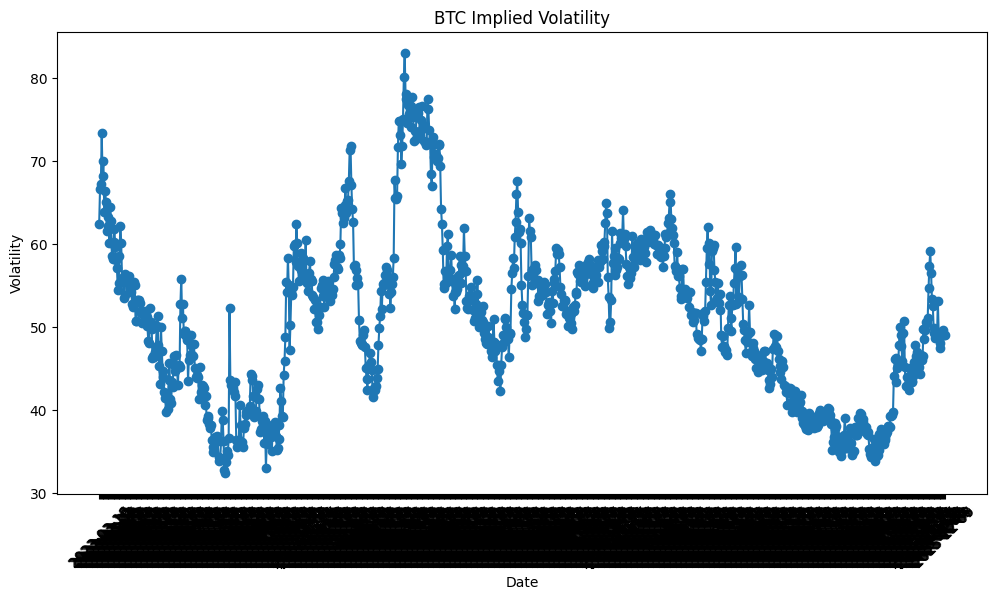

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['timestamp'], df['volatility'], marker='o', linestyle='-')
plt.title('BTC Implied Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.show()


In [ ]:
import requests
import pandas as pd
import datetime

currency = 'BTC'
resolution = '1D'
batch_size_days = 1000

# Earliest date
start_date = datetime.datetime(2018, 8, 8)
end_date = datetime.datetime.now()

all_data = []

current_start = start_date
while current_start < end_date:
    current_end = min(current_start + datetime.timedelta(days=batch_size_days), end_date)

    params = {
        'currency': currency,
        'start_timestamp': int(current_start.timestamp() * 1000),
        'end_timestamp': int(current_end.timestamp() * 1000),
        'resolution': resolution
    }

    url = "https://www.deribit.com/api/v2/public/get_volatility_index_data"
    response = requests.get(url, params=params)
    res_json = response.json()
    data = res_json.get('result', {}).get('data', [])
    if data:
        all_data.extend(data)

    current_start = current_end + datetime.timedelta(days=1)  # move to next batch

# Convert to DataFrame
if all_data:
    clean_data = [[row[0], row[4]] for row in all_data]  # timestamp & last column
    df = pd.DataFrame(clean_data, columns=['timestamp', 'volatility'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.to_csv(f'{currency}_DVOL_full.csv', index=False)
    print(f"Saved {currency}_DVOL_full.csv with {len(df)} rows")
else:
    print("No data returned")


Saved BTC_DVOL_full.csv with 1721 rows


In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv('BTC_DVOL_full.csv')

# Check first and last rows
print("First row:")
print(df.head(1))

print("\nLast row:")
print(df.tail(1))

# Or just the dates
print("\nStart date:", df['timestamp'].iloc[0])
print("End date:", df['timestamp'].iloc[-1])


First row:
    timestamp  volatility
0  2021-03-24       95.04

Last row:
       timestamp  volatility
1720  2025-12-09       48.98

Start date: 2021-03-24
End date: 2025-12-09


In [ ]:
params = {
    "currency": "BTC",
    "kind": "option",
    "expired": True  # Include expired options to see all historical instruments
}


In [ ]:
import requests
import pandas as pd

# Choose currency
currency = "BTC"

# Get all BTC option instruments, including expired
url = "https://www.deribit.com/api/v2/public/get_instruments"
params = {
    "currency": currency,
    "kind": "option",
    "expired": True  # Include expired options to see the earliest possible
}

response = requests.get(url, params=params)
res_json = response.json()

instruments = res_json.get("result", [])
print(f"Total instruments fetched: {len(instruments)}")

if instruments:
    # Convert to DataFrame
    df = pd.DataFrame(instruments)

    # Convert expiration timestamps to datetime
    df['expiration_datetime'] = pd.to_datetime(df['expiration_timestamp'], unit='ms')

    # Find earliest and latest expiration dates
    earliest_expiry = df['expiration_datetime'].min()
    latest_expiry = df['expiration_datetime'].max()

    print(f"Earliest expiry date for BTC options: {earliest_expiry}")
    print(f"Latest expiry date for BTC options: {latest_expiry}")

    # Optional: see first few instruments
    print(df[['instrument_name', 'strike', 'expiration_datetime', 'option_type']].head())
else:
    print("No instruments found.")


Total instruments fetched: 0
No instruments found.


In [ ]:
# Convert to DataFrame
df = pd.DataFrame(all_data)

# Check what columns we actually got
print(df.columns)

# Keep only relevant columns
# BitMEX returns: timestamp, fundingRate, symbol, fundingInterval, etc.
df = df[['timestamp', 'fundingRate', 'symbol']]

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Rename column for clarity
df.rename(columns={'timestamp': 'fundingTimestamp'}, inplace=True)

# Save CSV
df.to_csv('bitmex_funding.csv', index=False)
print("Saved funding rates to 'bitmex_funding.csv'")


Index(['timestamp', 'symbol', 'fundingInterval', 'fundingRate',
       'fundingRateDaily'],
      dtype='object')
Saved funding rates to 'bitmex_funding.csv'


In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv('bitmex_funding.csv')

# Show the first 10 rows
df.head(10)


,fundingTimestamp,fundingRate,symbol
0,2025-01-30 20:00:00+00:00,0.000100,XBTUSD
1,2025-01-30 12:00:00+00:00,0.000100,XBTUSD
2,2025-01-30 04:00:00+00:00,0.000100,XBTUSD
3,2025-01-29 20:00:00+00:00,0.000100,XBTUSD
4,2025-01-29 12:00:00+00:00,0.000100,XBTUSD
5,2025-01-29 04:00:00+00:00,0.000100,XBTUSD
6,2025-01-28 20:00:00+00:00,0.000036,XBTUSD
7,2025-01-28 12:00:00+00:00,-0.000005,XBTUSD
8,2025-01-28 04:00:00+00:00,0.000100,XBTUSD
9,2025-01-27 20:00:00+00:00,0.000100,XBTUSD


In [ ]:
!pip install bitmex

from bitmex import bitmex
import pandas as pd

# Initialize BitMEX client (you can use anonymous access for public data)
client = bitmex(test=False)

# Pull the first few funding rates
data = client.Funding.Funding_get(symbol='XBTUSD', count=1, reverse=False).result()[0]

# Convert to DataFrame
df = pd.DataFrame(data)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# See earliest timestamp
earliest = df['timestamp'].min()
latest = df['timestamp'].max()
print(f"Earliest funding rate timestamp available: {earliest}")
print(f"Latest funding rate timestamp available: {latest}")


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for bravado: filename=bravado-12.0.1-py2.py3-none-any.whl size=37492 sha256=3319db05528fe5507646593d325d1a4d4edf85dbac103e9dd3b0c855bcdaad62
  Stored in directory: /root/.cache/pip/wheels/02/14/f5/8086cc8a76021701714fe4a4e55668f42ffe811465266e820d
  Created wheel for bravado-core: filename=bravado_core-6.1.1-py2.py3-none-any.whl size=67675 sha256=062fed83fc5d62e0c62918c78326012d8c9f6c05a27fb59838f8df24bd659190
  Stored in directory: /root/.cache/pip/wheels/b8/56/c6/3695a1daf18ee45607f1d352fca288d173bc3b1722228c6fb1
Successfully built bravado bravado-core


/usr/local/lib/python3.12/dist-packages/swagger_spec_validator/validator20.py:49: SwaggerValidationWarning: Found "$ref: #/definitions/UserPreferences" with siblings that will be overwritten. See https://stackoverflow.com/a/48114924 for more information. (path #/definitions/User/properties/preferences)
  warnings.warn(


Earliest funding rate timestamp available: 2016-05-14 12:00:00+00:00
Latest funding rate timestamp available: 2016-05-14 12:00:00+00:00


In [ ]:
# Install BitMEX SDK if not installed
!pip install bitmex

from bitmex import bitmex
import pandas as pd
from datetime import datetime, timedelta

# Initialize BitMEX client (public data, no keys needed)
client = bitmex(test=False)

symbol = 'XBTUSD'
chunk_size = 100  # Max rows per API call
all_data = []

# Start from the earliest possible funding rate
# BitMEX API returns most recent first, so we'll reverse with 'reverse=True'
# We'll iterate by oldest timestamp so we don't miss any
start_time = None

while True:
    # Fetch a chunk
    data_chunk = client.Funding.Funding_get(
        symbol=symbol,
        count=chunk_size,
        startTime=start_time,
        reverse=False  # Get oldest first
    ).result()[0]

    if not data_chunk:
        break  # No more data

    all_data.extend(data_chunk)

    # Update start_time to last timestamp to get the next chunk
    last_time = pd.to_datetime(data_chunk[-1]['timestamp'])
    start_time = last_time + pd.Timedelta(seconds=1)  # Avoid duplicate

    print(f"Fetched {len(data_chunk)} rows, latest timestamp in chunk: {last_time}")

# Convert to DataFrame
df = pd.DataFrame(all_data)

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Save to CSV
csv_filename = 'bitmex_funding_full.csv'
df.to_csv(csv_filename, index=False)
print(f"Saved {len(df)} rows to {csv_filename}")

# Show head and tail
print("Head:")
print(df.head())
print("\nTail:")
print(df.tail())


/usr/local/lib/python3.12/dist-packages/swagger_spec_validator/validator20.py:49: SwaggerValidationWarning: Found "$ref: #/definitions/UserPreferences" with siblings that will be overwritten. See https://stackoverflow.com/a/48114924 for more information. (path #/definitions/User/properties/preferences)
  warnings.warn(


Fetched 100 rows, latest timestamp in chunk: 2016-06-30 12:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2016-08-02 20:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2016-09-05 04:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2016-10-08 12:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2016-11-10 20:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2016-12-14 04:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2017-01-16 12:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2017-02-18 20:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2017-03-24 04:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2017-04-26 12:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2017-05-29 20:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2017-07-02 04:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2017-08-04 12:00:00+00:00
Fetched 100 rows, latest timestamp in chunk: 2017-09-06 20:00:00+00:00
Fetche

In [ ]:
import os
import pandas as pd

# Example: set a folder inside your Drive where you want to save CSVs
output_folder = '/content/drive/MyDrive/top1000_tokens_20251008_154804'
os.makedirs(output_folder, exist_ok=True)  # creates folder if it doesn't exist

# Example: save a single DataFrame to CSV
df = pd.DataFrame({
    'timestamp': ['2025-01-01', '2025-01-02'],
    'fundingRate': [0.0001, 0.0002],
    'symbol': ['XBTUSD', 'XBTUSD']
})

df.to_csv(os.path.join(output_folder, 'funding_rates.csv'), index=False)

print("✅ CSV saved to Google Drive!")


✅ CSV saved to Google Drive!


In [ ]:
import os

# Path to your features folder in Drive
feature_folder = "/content/drive/MyDrive/token_features_generated"
os.makedirs(feature_folder, exist_ok=True)  # ensure folder exists

# Save funding rates directly to Drive
csv_drive_path = os.path.join(feature_folder, "funding_rates.csv")
df.to_csv(csv_drive_path, index=False)

print(f"✅ Funding rates saved to Google Drive at {csv_drive_path}")


✅ Funding rates saved to Google Drive at /content/drive/MyDrive/token_features_generated/funding_rates.csv


In [ ]:
import os

path = "/content/drive/MyDrive/token_features_generated"

print("Folder exists:", os.path.exists(path))
print("Files in folder:")
print(os.listdir(path))


Folder exists: True
Files in folder:
['funding_rates.csv']


In [ ]:
from google.colab import drive
drive.mount("/content/drive")


ValueError: Mountpoint must not already contain files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive



my_csv_folder  token_features_generated  top1000_tokens_20251008_154804


In [ ]:
# Install BitMEX SDK if not already installed
!pip install bitmex

from bitmex import bitmex
import pandas as pd

# Initialize BitMEX client (public data, no API keys needed for reading data)
client = bitmex(test=False)

# Choose symbol
symbol = 'XBTUSD'

# Fetch instrument info
instrument_data = client.Instrument.Instrument_get(symbol=symbol).result()[0]

# instrument_data is a list, take the first entry
instrument = instrument_data[0]

# Extract open interest
oi = instrument['openInterest']
timestamp = instrument['timestamp']

print(f"Symbol: {symbol}")
print(f"Timestamp: {timestamp}")
print(f"Open Interest: {oi}")


Symbol: XBTUSD
Timestamp: 2025-12-23 00:32:20.500000+00:00
Open Interest: 210095300


In [ ]:
# Install BitMEX SDK if not installed
!pip install bitmex

from bitmex import bitmex
import pandas as pd
from datetime import datetime, timedelta

# Initialize BitMEX client (public data, no keys needed)
client = bitmex(test=False)

symbol = 'XBTUSD'
chunk_size = 100  # Number of rows per API call
all_data = []

# Start with no startTime to get the most recent data first
start_time = None

while True:
    # Fetch a chunk of instruments
    data_chunk = client.Instrument.Instrument_get(
        symbol=symbol,
        count=chunk_size,
        startTime=start_time,
        reverse=True  # Oldest first
    ).result()[0]

    if not data_chunk:
        break  # No more data

    all_data.extend(data_chunk)

    # Print the earliest timestamp in this chunk
    earliest_time = pd.to_datetime(data_chunk[0]['timestamp'])
    latest_time = pd.to_datetime(data_chunk[-1]['timestamp'])
    print(f"Fetched {len(data_chunk)} rows | Earliest: {earliest_time} | Latest: {latest_time}")

    # Update start_time to earliest timestamp to fetch older data
    start_time = earliest_time - pd.Timedelta(seconds=1)

    # Stop after 1 chunk for testing
    break

# Convert to DataFrame
df = pd.DataFrame(all_data)

# Show what fields are returned
print(df.columns)

# Show timestamps and open interest
print(df[['timestamp', 'openInterest']])


Fetched 1 rows | Earliest: 2025-12-23 01:15:26.710000+00:00 | Latest: 2025-12-23 01:15:26.710000+00:00
Index(['symbol', 'rootSymbol', 'state', 'typ', 'listing', 'front',
       'positionCurrency', 'underlying', 'quoteCurrency', 'underlyingSymbol',
       'reference', 'referenceSymbol', 'maxOrderQty', 'maxPrice', 'lotSize',
       'tickSize', 'multiplier', 'settlCurrency',
       'underlyingToSettleMultiplier', 'isQuanto', 'isInverse', 'initMargin',
       'maintMargin', 'riskLimit', 'riskStep', 'taxed', 'deleverage',
       'makerFee', 'takerFee', 'settlementFee', 'fundingBaseSymbol',
       'fundingQuoteSymbol', 'fundingPremiumSymbol', 'fundingTimestamp',
       'fundingInterval', 'fundingRate', 'indicativeFundingRate',
       'prevClosePrice', 'limitDownPrice', 'limitUpPrice', 'prevTotalVolume',
       'totalVolume', 'volume', 'volume24h', 'prevTotalTurnover',
       'totalTurnover', 'turnover', 'turnover24h', 'homeNotional24h',
       'foreignNotional24h', 'prevPrice24h', 'vwap', 'h

In [ ]:
# Show head
print("\nHead:")
print(df.head())

# Show tail
print("\nTail:")
print(df.tail())



Head:
   symbol rootSymbol state     typ                   listing  \
0  XBTUSD        XBT  Open  FFWCSX 2016-05-13 12:00:00+00:00   

                      front positionCurrency underlying quoteCurrency  \
0 2016-05-13 12:00:00+00:00              USD        XBT           USD   

  underlyingSymbol  ... publishInterval publishTime  \
0             XBT=  ...            None        None   

   underlyingToPositionMultiplier  quoteToSettleMultiplier  limit  \
0                            None                     None   None   

   rebalanceTimestamp  rebalanceInterval launchingTimestamp  \
0                None               None               None   

   settledPriceAdjustmentRate  settledPrice  
0                        None          None  

[1 rows x 96 columns]

Tail:
   symbol rootSymbol state     typ                   listing  \
0  XBTUSD        XBT  Open  FFWCSX 2016-05-13 12:00:00+00:00   

                      front positionCurrency underlying quoteCurrency  \
0 2016-05-13 12:

In [ ]:
!pip install bitmex

from bitmex import bitmex
import pandas as pd
from datetime import timedelta

# Initialize BitMEX client
client = bitmex(test=False)

symbol = 'XBTUSD'
chunk_size = 100
start_time = None
earliest_row = None

while True:
    # Fetch a chunk
    data_chunk = client.Instrument.Instrument_get(
        symbol=symbol,
        count=chunk_size,
        startTime=start_time,
        reverse=True  # Oldest first
    ).result()[0]

    if not data_chunk:
        break

    # The earliest row in this chunk
    earliest_row = data_chunk[0]

    # Update start_time to go further back
    start_time = pd.to_datetime(earliest_row['timestamp'], utc=True) - timedelta(seconds=1)

    # Stop if we reach very early data (BitMEX XBTUSD listing)
    if start_time <= pd.to_datetime('2016-05-13 12:00:00', utc=True):
        break

# Print the earliest row
print("Earliest available perpetual OI row:")
print(earliest_row)


HTTPTooManyRequests: 429 Too Many Requests: Response specification matching http status_code 429 not found for operation Operation(Instrument_get). Either add a response specification for the status_code or use a `default` response.